In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    # For fixed-size inputs enabling benchmark improves throughput;
    # set deterministic to False to allow faster CuDNN kernels (affects exact reproducibility).
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
scaler = torch.cuda.amp.GradScaler()


Using device: cuda


In [2]:
from pathlib import Path
base_dir = Path('C:/Users/admin/Downloads/Infection Segmentation Data')

train_img_dir = base_dir / 'Train' / 'COVID-19' / 'images'
train_mask_dir = base_dir / 'Train' / 'COVID-19' / 'infection masks'

val_img_dir = base_dir / 'Val' / 'COVID-19' / 'images'
val_mask_dir = base_dir / 'Val' / 'COVID-19' / 'infection masks'

test_img_dir = base_dir / 'Test' / 'COVID-19' / 'images'
test_mask_dir = base_dir / 'Test' / 'COVID-19' / 'infection masks'

print("Checking dataset paths...\n")
paths_to_check = [
    ('Train Images', train_img_dir),
    ('Train Masks', train_mask_dir),
    ('Val Images', val_img_dir),
    ('Val Masks', val_mask_dir),
    ('Test Images', test_img_dir),
    ('Test Masks', test_mask_dir)
]

all_exist = True
for name, path in paths_to_check:
    if path.exists():
        num_files = len(list(path.glob('*.png')))
        print(f"{name:15s}: {path} ({num_files} files)")
    else:
        print(f"{name:15s}: {path} - NOT FOUND")
        all_exist = False

if not all_exist:
    print("WARNING: Some paths do not exist!")
    print("Please verify your dataset location and update the base_dir variable.")
else:
    print("All dataset paths verified successfully!")



Checking dataset paths...

Train Images   : C:\Users\admin\Downloads\Infection Segmentation Data\Train\COVID-19\images (1864 files)
Train Masks    : C:\Users\admin\Downloads\Infection Segmentation Data\Train\COVID-19\infection masks (1864 files)
Val Images     : C:\Users\admin\Downloads\Infection Segmentation Data\Val\COVID-19\images (466 files)
Val Masks      : C:\Users\admin\Downloads\Infection Segmentation Data\Val\COVID-19\infection masks (466 files)
Test Images    : C:\Users\admin\Downloads\Infection Segmentation Data\Test\COVID-19\images (583 files)
Test Masks     : C:\Users\admin\Downloads\Infection Segmentation Data\Test\COVID-19\infection masks (583 files)
All dataset paths verified successfully!


In [3]:
class COVID19Dataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, img_size=256):
        self.transform = transform
        self.img_size = img_size
        
        image_files = sorted(list(Path(image_dir).glob('*.png')))
        
        self.images = []
        self.masks = []
        
        for img_path in tqdm(image_files, desc="Loading dataset into RAM"):
            mask_path = Path(mask_dir) / img_path.name
            if not mask_path.exists():
                continue
            
            image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            
            image = cv2.resize(image, (img_size, img_size))
            mask = cv2.resize(mask, (img_size, img_size))
            
            image = (image.astype(np.float32) / 255.0)
            mask = (mask > 0.5).astype(np.float32)
            
            self.images.append(image)
            self.masks.append(mask)
        
        print(f"Loaded {len(self.images)} image-mask pairs into RAM")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        image = torch.from_numpy(image).unsqueeze(0).float()

        mask = np.where(mask == 128, 1, mask)
        mask = np.where(mask == 255, 2, mask)
        mask = torch.from_numpy(mask).long()

        return image, mask
        
      

In [4]:
train_dataset = COVID19Dataset(train_img_dir, train_mask_dir, img_size=256)
val_dataset = COVID19Dataset(val_img_dir, val_mask_dir, img_size=256)
test_dataset = COVID19Dataset(test_img_dir, test_mask_dir, img_size=256)

print(f"\nDataset sizes:")
print(f"Train: {len(train_dataset)} samples")
print(f"Validation: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")
print(f"Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)} samples")

Loading dataset into RAM: 100%|██████████| 1864/1864 [00:05<00:00, 341.92it/s]


Loaded 1864 image-mask pairs into RAM


Loading dataset into RAM: 100%|██████████| 466/466 [00:01<00:00, 342.58it/s]


Loaded 466 image-mask pairs into RAM


Loading dataset into RAM: 100%|██████████| 583/583 [00:01<00:00, 343.37it/s]

Loaded 583 image-mask pairs into RAM

Dataset sizes:
Train: 1864 samples
Validation: 466 samples
Test: 583 samples
Total: 2913 samples


In [5]:
# Tunable data-loading parameters for better throughput
batch_size = 16  # consider increasing if GPU memory allows
# Use multiple workers (CPU cores minus one), capped to avoid too many processes on small machines
num_workers = 0 if os.name == 'nt' else min(4, os.cpu_count() - 1)
pin_memory = True if torch.cuda.is_available() else False

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)
print(f"\nDataLoader settings:")
print(f" batch_size: {batch_size}, num_workers: {num_workers}, pin_memory: {pin_memory}")
print(f"Train: {len(train_loader)} batches")
print(f"Validation: {len(val_loader)} batches")
print(f"Test: {len(test_loader)} batches")


DataLoader settings:
 batch_size: 16, num_workers: 0, pin_memory: True
Train: 117 batches
Validation: 30 batches
Test: 583 batches


In [6]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)

In [8]:
class ResidualDoubleConv(nn.Module):
    """Residual version (helps stability with small datasets)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            ConvBNReLU(in_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )
        self.skip = (
            nn.Identity()
            if in_ch == out_ch
            else nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.conv(x) + self.skip(x))

In [9]:
class UpConv(nn.Module):
    """Upsample + 1x1/3x3 conv for channel adjustment."""
    def __init__(self, in_ch, out_ch, mode="bilinear"):
        super().__init__()
        self.mode = mode
        if mode == "transpose":
            self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        else:
            self.up = nn.Sequential(
                nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            )

    def forward(self, x):
        return self.up(x)

In [10]:
class AttentionGate(nn.Module):
    """
    g: gating signal (from decoder, coarser)
    x: skip connection (from encoder, finer)
    returns: attended skip features
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # Ensure same spatial size (should match if your UNet is consistent)
        if g.shape[-2:] != x.shape[-2:]:
            g = F.interpolate(g, size=x.shape[-2:], mode="bilinear", align_corners=False)

        psi = self.relu(self.W_g(g) + self.W_x(x))
        alpha = self.psi(psi)  # (B,1,H,W)
        return x * alpha


In [11]:
class AttentionUNet(nn.Module):
    """
    Attention U-Net for 2D segmentation.

    Args:
        in_channels: 1 (CT) or 3 (RGB)
        num_classes: 1 for binary mask (use sigmoid), >1 for multiclass (use softmax)
        base_ch: width of the network
        use_residual: True -> ResidualDoubleConv, False -> DoubleConv
        up_mode: "bilinear" or "transpose"
    """
    def __init__(self, in_channels=1, num_classes=3, base_ch=64, use_residual=True, up_mode="bilinear"):
        super().__init__()
        Block = ResidualDoubleConv if use_residual else DoubleConv

        # Encoder
        self.enc1 = Block(in_channels, base_ch)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = Block(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = Block(base_ch * 2, base_ch * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = Block(base_ch * 4, base_ch * 8)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = Block(base_ch * 8, base_ch * 16)

        # Decoder + attention gates
        self.up4 = UpConv(base_ch * 16, base_ch * 8, mode=up_mode)
        self.att4 = AttentionGate(F_g=base_ch * 8, F_l=base_ch * 8, F_int=base_ch * 4)
        self.dec4 = Block(base_ch * 16, base_ch * 8)

        self.up3 = UpConv(base_ch * 8, base_ch * 4, mode=up_mode)
        self.att3 = AttentionGate(F_g=base_ch * 4, F_l=base_ch * 4, F_int=base_ch * 2)
        self.dec3 = Block(base_ch * 8, base_ch * 4)

        self.up2 = UpConv(base_ch * 4, base_ch * 2, mode=up_mode)
        self.att2 = AttentionGate(F_g=base_ch * 2, F_l=base_ch * 2, F_int=base_ch)
        self.dec2 = Block(base_ch * 4, base_ch * 2)

        self.up1 = UpConv(base_ch * 2, base_ch, mode=up_mode)
        self.att1 = AttentionGate(F_g=base_ch, F_l=base_ch, F_int=base_ch // 2)
        self.dec1 = Block(base_ch * 2, base_ch)

        # Output
        self.out_conv = nn.Conv2d(base_ch, num_classes, kernel_size=1)

        # Init
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1.0)
            nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Bottleneck
        b  = self.bottleneck(self.pool4(e4))

        # Decoder
        d4 = self.up4(b)
        e4_att = self.att4(g=d4, x=e4)
        d4 = self.dec4(torch.cat([d4, e4_att], dim=1))

        d3 = self.up3(d4)
        e3_att = self.att3(g=d3, x=e3)
        d3 = self.dec3(torch.cat([d3, e3_att], dim=1))

        d2 = self.up2(d3)
        e2_att = self.att2(g=d2, x=e2)
        d2 = self.dec2(torch.cat([d2, e2_att], dim=1))

        d1 = self.up1(d2)
        e1_att = self.att1(g=d1, x=e1)
        d1 = self.dec1(torch.cat([d1, e1_att], dim=1))

        logits = self.out_conv(d1)
        return logits

In [12]:
class DiceLossMulti(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        logits:  (B, C, H, W)
        targets: (B, H, W)  integer labels {0,1,2}
        """
        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)

        targets_onehot = torch.nn.functional.one_hot(
            targets, num_classes
        ).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        cardinality  = torch.sum(probs + targets_onehot, dims)

        dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()


class DiceCELoss(nn.Module):
    def __init__(self, dice_weight=0.6, ce_weight=0.4):
        super().__init__()
        self.dice = DiceLossMulti()
        self.ce = nn.CrossEntropyLoss()
        self.dw = dice_weight
        self.cw = ce_weight

    def forward(self, logits, targets):
        """
        logits:  (B, C, H, W)  float
        targets: (B, H, W)     long
        """
        loss_dice = self.dice(logits, targets)
        loss_ce = self.ce(logits, targets)
        return self.dw * loss_dice + self.cw * loss_ce

In [13]:
if __name__ == "__main__":
    model = AttentionUNet(in_channels=1, num_classes=3, base_ch=32, use_residual=True).cuda()
    x = torch.randn(1, 1, 256, 256).cuda()
    logits = model(x)
    print("logits:", logits.shape)  # (2,1,256,256)


logits: torch.Size([1, 3, 256, 256])


In [14]:
model = AttentionUNet(
    in_channels=1,     
    num_classes=3,     
    base_ch=16,        
    use_residual=True
).to(device)
criterion = DiceCELoss(dice_weight=0.6, ce_weight=0.4)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

x = torch.randn(1, 1, 256, 256).to(device)
output = model(x)
print(f'Input shape: {x.shape}')
print(f'Output shape: {output.shape}')

Input shape: torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 3, 256, 256])


In [15]:
loss_functions = {
    'CrossEntropy': nn.CrossEntropyLoss(),
    'DiceCE': DiceCELoss(dice_weight=0.6, ce_weight=0.4)
}

print('Loss functions defined:')
for name in loss_functions.keys():
    print(f'  - {name}')

Loss functions defined:
  - CrossEntropy
  - DiceCE


In [16]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True).long().squeeze(1)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    dice_vals = []
    iou_vals  = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.to(device).long()
            masks  = masks.squeeze(1)  # (B,H,W)

            logits = model(images)                  # (B,3,H,W)
            loss = criterion(logits, masks)

            metrics = calculate_metrics(logits, masks)

            running_loss += loss.item()
            dice_vals.append(metrics["dice_mean"])
            iou_vals.append(metrics["iou_mean"])

    return {
        "loss": running_loss / len(loader),
        "dice": float(np.mean(dice_vals)),
        "iou":  float(np.mean(iou_vals)),
    }


def calculate_metrics(logits, targets, num_classes=3, eps=1e-7):
    """
    logits:  (B, C, H, W)
    targets: (B, H, W) long
    returns: dict with mean Dice and IoU
    """
    with torch.no_grad():
        preds = torch.argmax(logits, dim=1)  # (B, H, W)

        dice_scores = []
        iou_scores = []

        for c in range(num_classes):
            pred_c = (preds == c).float()
            targ_c = (targets == c).float()

            intersection = (pred_c * targ_c).sum()
            union = pred_c.sum() + targ_c.sum()

            dice = (2 * intersection + eps) / (union + eps)
            iou  = (intersection + eps) / (pred_c.sum() + targ_c.sum() - intersection + eps)

            dice_scores.append(dice.item())
            iou_scores.append(iou.item())

        return {
            "dice_mean": float(np.mean(dice_scores)),
            "iou_mean":  float(np.mean(iou_scores)),
        }




In [17]:
num_epochs = 10
learning_rate = 0.001
# Model width (reduce for faster experiments). Increase if you want better capacity.
train_base_ch = 16

models_dict = {}
history = {}
loss_functions = {
    'CrossEntropy': nn.CrossEntropyLoss(),
    'DiceCE': DiceCELoss(dice_weight=0.6, ce_weight=0.4)
}

for loss_name, criterion in loss_functions.items():
    print(f"Training with {loss_name} loss function")
    
    model = AttentionUNet(in_channels=1, num_classes=3, base_ch=train_base_ch, use_residual=True).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for images, masks in loop:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True).long().squeeze(1)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_losses.append(total_loss / len(train_loader))  # ← use accumulated loss

        val_metrics = validate(model, val_loader, criterion, device)
        val_losses.append(val_metrics['loss'])
    
    models_dict[loss_name] = model
    history[loss_name] = {
        'train_loss': train_losses,
        'val_loss': val_losses
    }
    
    print(f"  Training completed for {loss_name}")
    print(f"  Final Train Loss: {train_losses[-1]:.6f}")
    print(f"  Final Val Loss: {val_losses[-1]:.6f}")

print("\n" + "="*60)
print("All training completed!")
print("="*60)

Training with CrossEntropy loss function


Epoch 10/10: 100%|██████████| 117/117 [03:06<00:00,  1.60s/it, loss=0.297] 


  Training completed for CrossEntropy
  Final Train Loss: 0.106227
  Final Val Loss: 0.137170
Training with DiceCE loss function


Epoch 10/10: 100%|██████████| 117/117 [03:09<00:00,  1.62s/it, loss=0.0976]


  Training completed for DiceCE
  Final Train Loss: 0.180056
  Final Val Loss: 0.118984

All training completed!


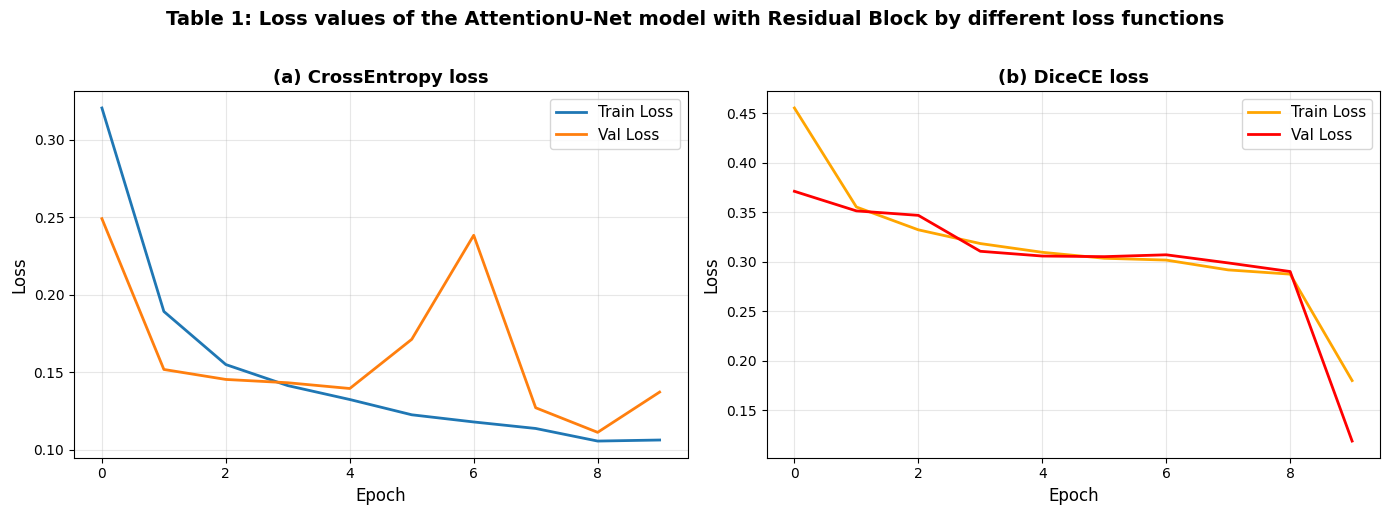

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['CrossEntropy']['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['CrossEntropy']['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('(a) CrossEntropy loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['DiceCE']['train_loss'], label='Train Loss', linewidth=2, color='orange')
axes[1].plot(history['DiceCE']['val_loss'], label='Val Loss', linewidth=2, color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('(b) DiceCE loss', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Table 1: Loss values of the AttentionU-Net model with Residual Block by different loss functions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('table1_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
test_results = {}

for loss_name, model in models_dict.items():
    model.eval()
    
    all_mae = []
    all_iou = []
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc=f'Evaluating {loss_name}'):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            
            metrics = calculate_metrics(outputs, masks)

            dice = metrics['dice_mean']
            iou = metrics['iou_mean']

            all_mae.append(dice)
            all_iou.append(iou)
    
    test_results[loss_name] = {
        'MAE': np.mean(all_mae),
        'IoU': np.mean(all_iou)
    }

results_df = pd.DataFrame(test_results).T
results_df.index.name = 'Loss function'

print("Table 2: MAE and IoU values on test dataset")
print(results_df.to_string())

results_df.to_csv('table2_metrics.csv')

Evaluating DiceCE: 100%|██████████| 583/583 [00:18<00:00, 30.95it/s]

Table 2: MAE and IoU values on test dataset
                    MAE       IoU
Loss function                    
CrossEntropy   0.864814  0.812216
DiceCE         0.892660  0.840353


Table 3: Accuracy and confusion matrix on test dataset

=== CrossEntropy ===
Accuracy: 0.9354
Confusion matrix (rows=true, cols=pred):
[[32555477   342227]
 [ 2124716  3185068]]


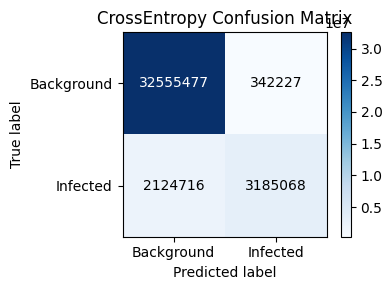


=== DiceCE ===
Accuracy: 0.9417
Confusion matrix (rows=true, cols=pred):
[[31715590  1182114]
 [ 1044590  4265194]]


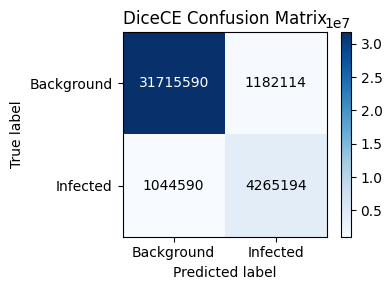

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Table 3: Accuracy and confusion matrix on test dataset")

for loss_name, model in models_dict.items():
    model.eval()
    all_trues = []
    all_preds = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.softmax(outputs, dim=1)
            preds = torch.argmax(preds, dim=1)

            all_trues.append(masks.view(-1).cpu().numpy())
            all_preds.append(preds.view(-1).cpu().numpy())

    y_true = np.concatenate(all_trues)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n=== {loss_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)

    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=['Background', 'Infected'],
        yticklabels=['Background', 'Infected'],
        title=f"{loss_name} Confusion Matrix",
        ylabel='True label',
        xlabel='Predicted label'
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


In [21]:
def visualize_segmentation(models_dict, test_dataset, image_idx, save_name, title):
    image, mask = test_dataset[image_idx]
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes[0, 0].imshow(image.squeeze().cpu().numpy(), cmap='gray')
    axes[0, 0].set_title('Original Image', fontsize=11, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(image.squeeze().cpu().numpy(), cmap='gray')
    axes[0, 2].set_title('Original Image', fontsize=11, fontweight='bold')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(mask.squeeze().cpu().numpy(), cmap='gray')
    axes[1, 0].set_title('Ground-truth', fontsize=11, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(mask.squeeze().cpu().numpy(), cmap='gray')
    axes[1, 2].set_title('Ground-truth', fontsize=11, fontweight='bold')
    axes[1, 2].axis('off')
    
    loss_names = ['CrossEntropy', 'DiceCE']
    
    for idx, loss_name in enumerate(loss_names):
        model = models_dict[loss_name]
        model.eval()
        
        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device))
            pred = torch.softmax(pred, dim=1)      # convert logits to probabilities
            pred = torch.argmax(pred, dim=1)       # get predicted class per pixel
            pred = pred.squeeze().cpu().numpy()    # shape becomes (H, W)
        
        col_idx = idx * 2  
        axes[2, col_idx].imshow(pred, cmap='gray')
        axes[2, col_idx].set_title(f'Predicted infected area', fontsize=11, fontweight='bold')
        axes[2, col_idx].axis('off')
    
    
    axes[2, 1].axis('off')
    
    fig.text(0.25, 0.95, 'BCE loss', ha='center', fontsize=13, fontweight='bold')
    fig.text(0.75, 0.95, 'MSE loss', ha='center', fontsize=13, fontweight='bold')
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    
    return save_name


Generating Figure 1 (Image 151)...


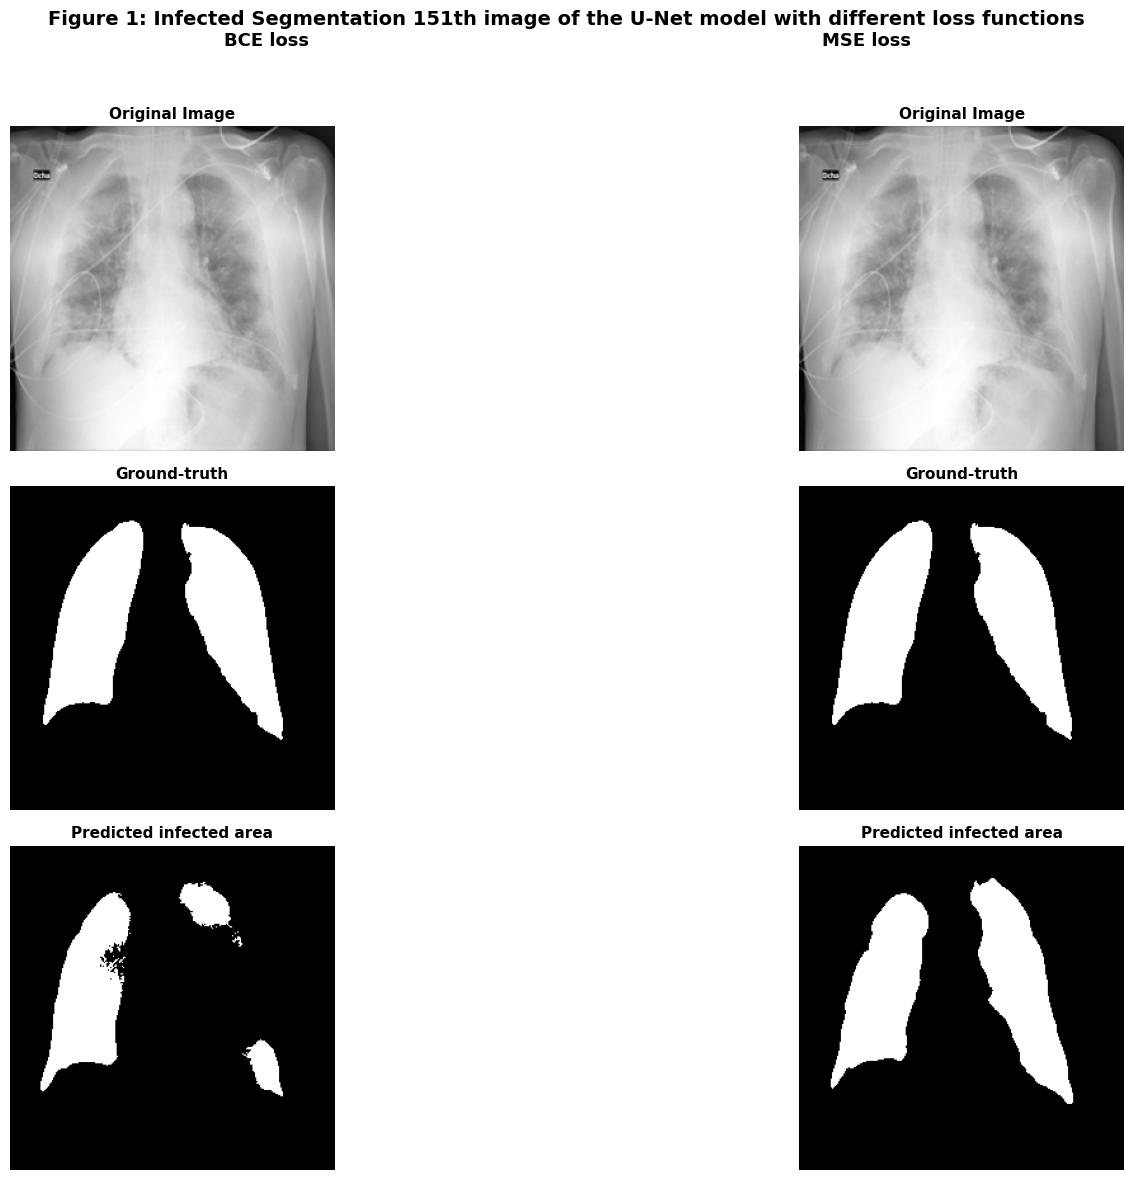


Generating Figure 2 (Image 156)...


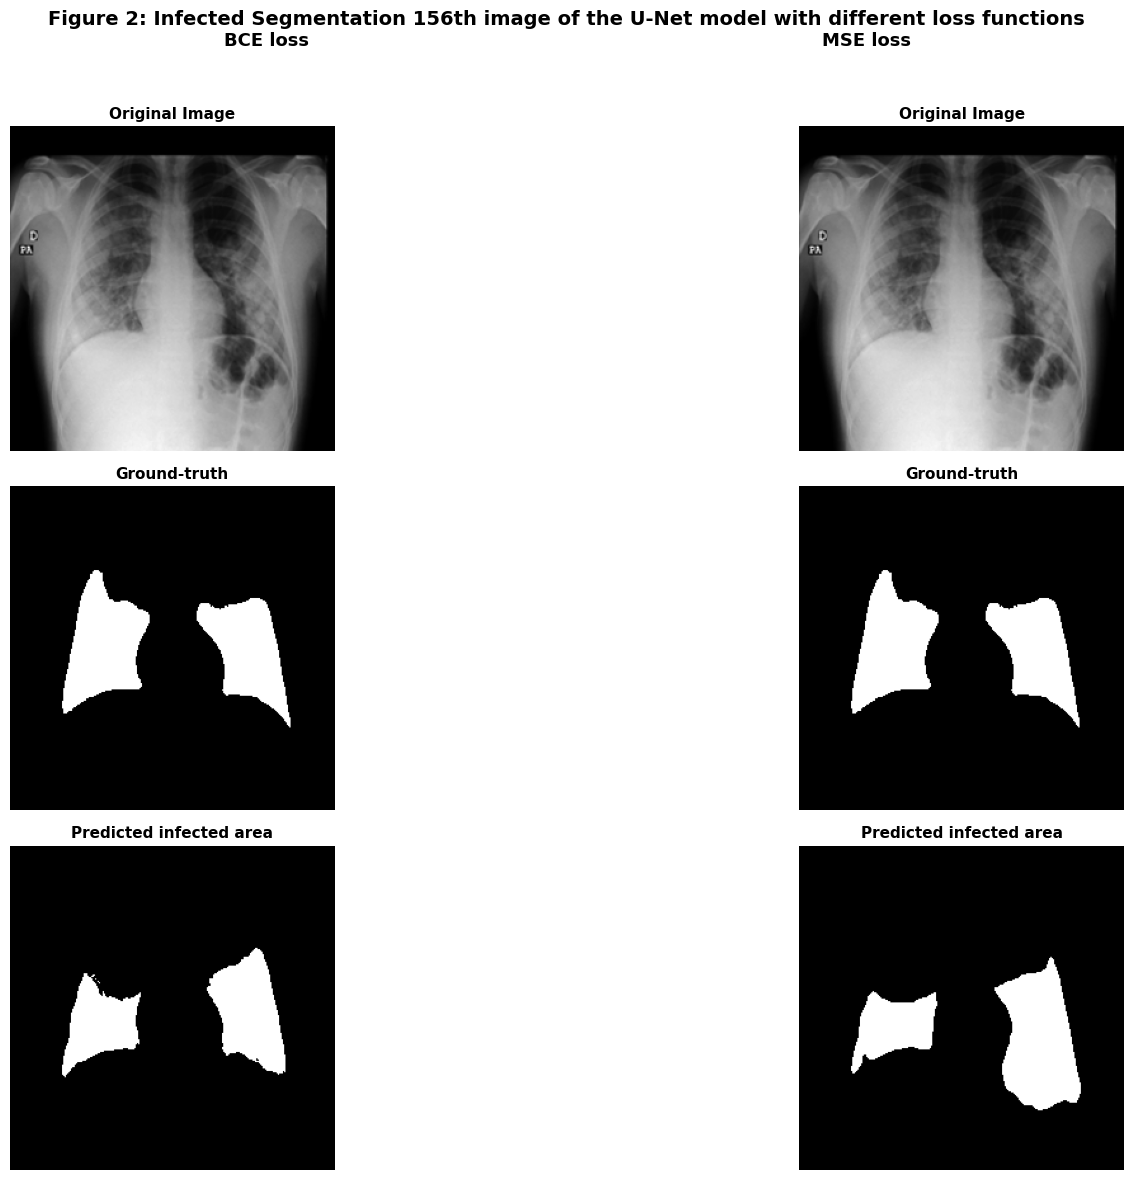


Generating Figure 3 (Image 191)...


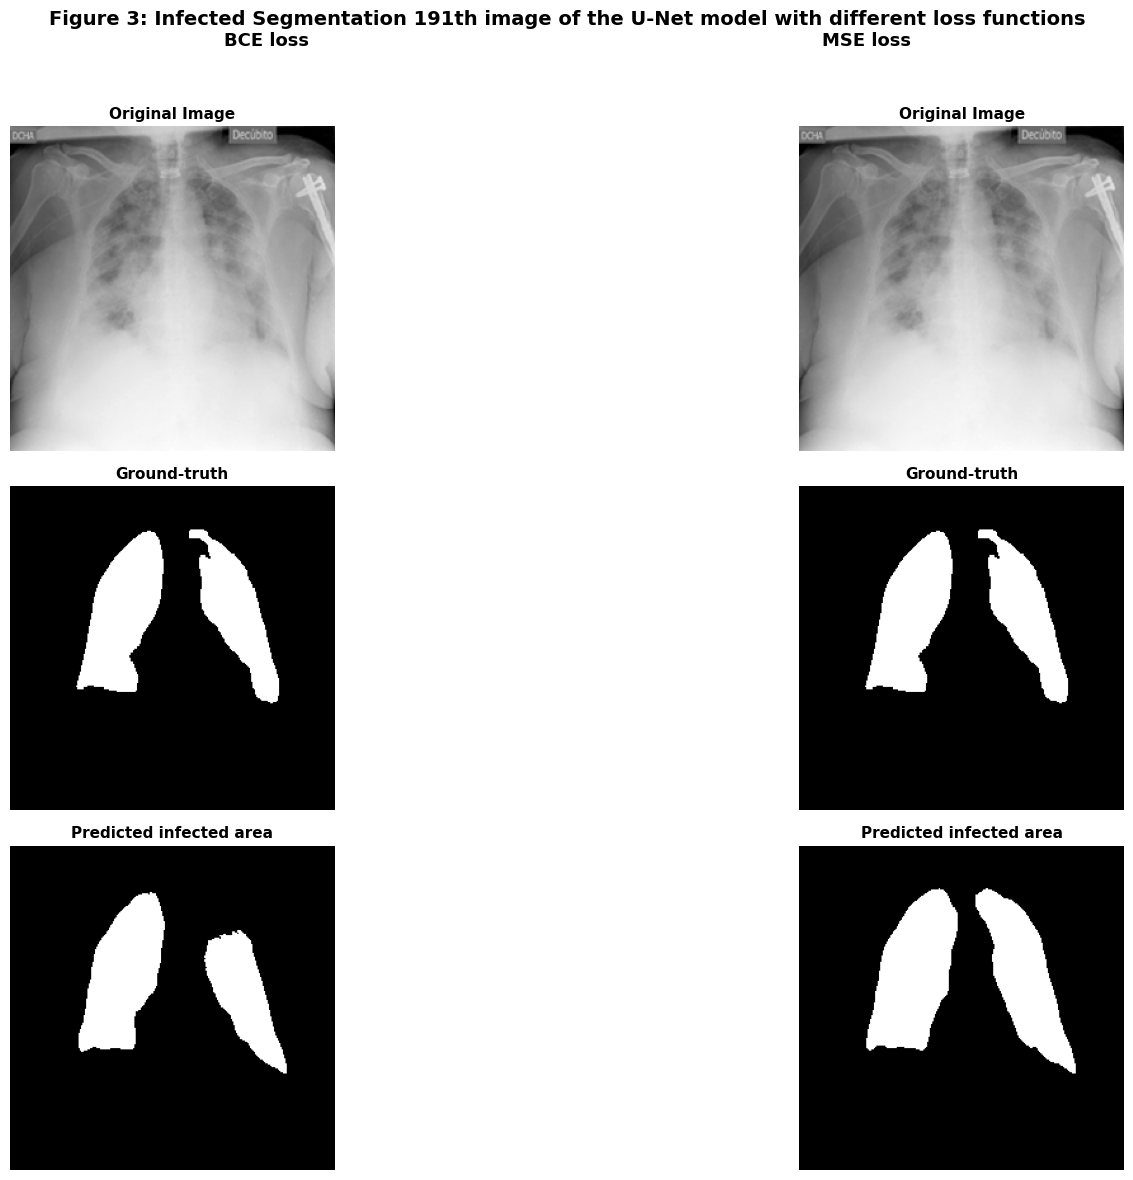

In [22]:
test_indices = [150, 155, 190]  
figure_numbers = [1, 2, 3]

saved_figures = []

for test_idx, fig_num in zip(test_indices, figure_numbers):
    actual_image_num = test_idx + 1  
    
    print(f'\nGenerating Figure {fig_num} (Image {actual_image_num})...')
    
    save_name = f'figure{fig_num}_infected_segmentation_{actual_image_num}th.png'
    title = f'Figure {fig_num}: Infected Segmentation {actual_image_num}th image of the U-Net model with different loss functions'
    
    visualize_segmentation(models_dict, test_dataset, test_idx, save_name, title)
    saved_figures.append((fig_num, save_name, actual_image_num))